In [8]:
!rm -rf cats_dogs_data

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.5161 - loss: 0.6956 - val_accuracy: 0.6221 - val_loss: 0.6752 - learning_rate: 0.0010
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 156ms/step - accuracy: 0.5896 - loss: 0.6753 - val_accuracy: 0.5471 - val_loss: 0.6706 - learning_rate: 0.0010
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.6108 - loss: 0.6571 - val_accuracy: 0.6721 - val_loss: 0.6374 - learning_rate: 0.0010
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.6051 - loss: 0.6621 - val_accuracy: 0.6632 - val_loss: 0.6253 - learning_rate: 0.0010
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.6620 - loss: 0.6281 - val_accuracy: 0.6750 - val_loss: 0.5988 - learning_rate: 0.0010
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - accuracy: 0.6530 - loss: 0.6292 - val_accuracy: 0.7176 - val_loss: 0.5790 - learning_rate: 0.0010
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.6667 - loss: 0.

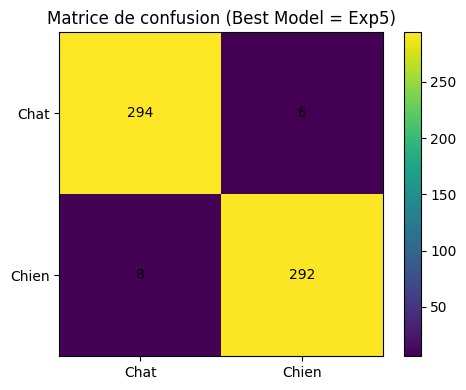

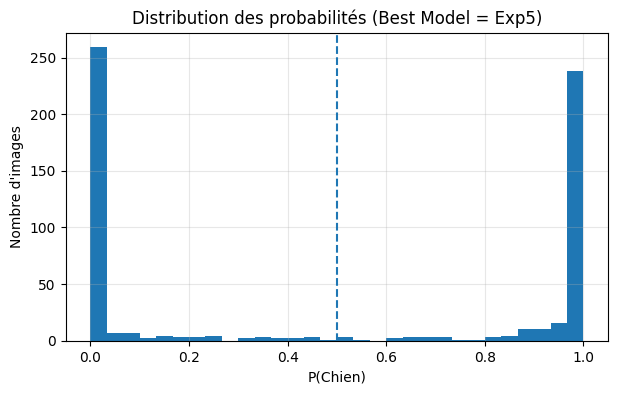

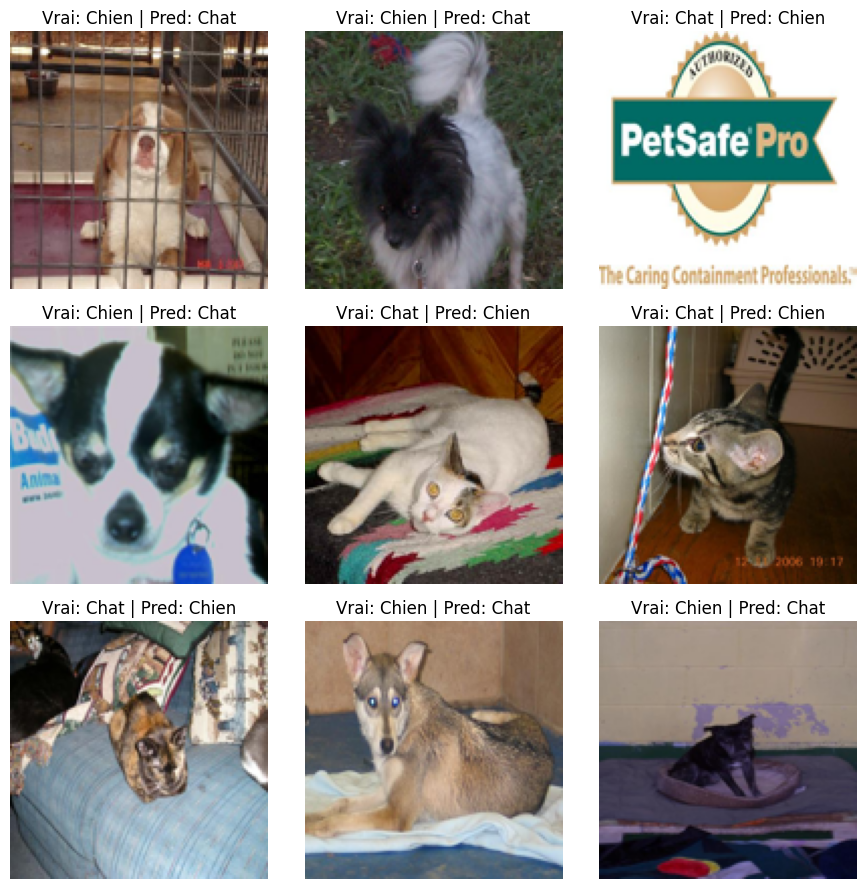

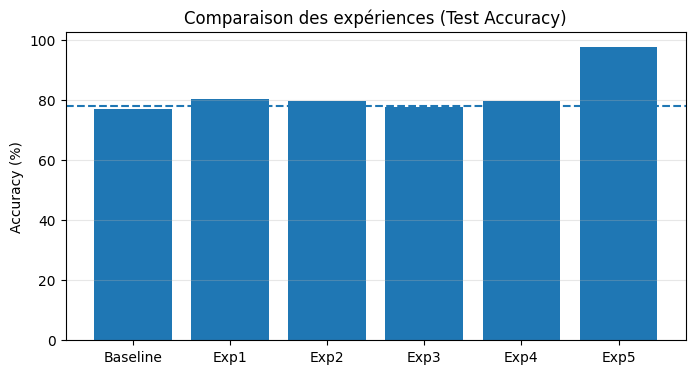

In [13]:
# =========================
# Imports
# =========================
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
from PIL import Image

# =========================
# Configuration
# =========================
ZIP_PATH = "/content/drive/MyDrive/kagglecatsanddogs_5340.zip"
DATA_DIR = "cats_dogs_data"

IMG_SIZE = 128
MAX_IMAGES_PER_CLASS = 2000
RANDOM_STATE = 42

BATCH_SIZE = 32

# =========================
# Chargement des données
# =========================
def load_cats_dogs(zip_path=ZIP_PATH, data_dir=DATA_DIR, img_size=IMG_SIZE, max_per_class=MAX_IMAGES_PER_CLASS):
    """
    Extrait le zip et charge les images de chats et chiens.
    Retourne X (N,H,W,3) uint8 et y (N,) int: 0=Chat, 1=Chien.
    """
    data_dir = Path(data_dir)

    if not Path(zip_path).exists():
        raise FileNotFoundError(f"ZIP introuvable: {zip_path}")

    # Extraire (si nécessaire)
    if not data_dir.exists():
        data_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(str(data_dir))

    # Dossiers attendus
    base_dir = data_dir / "PetImages"
    cat_dir = base_dir / "Cat"
    dog_dir = base_dir / "Dog"

    if not cat_dir.exists() or not dog_dir.exists():
        raise FileNotFoundError(
            f"Dossiers Cat/Dog introuvables.\nAttendu:\n{cat_dir}\n{dog_dir}\n"
            f"Contenu de {data_dir}: {list(data_dir.iterdir())}"
        )

    X, y = [], []
    for label, folder_path in [(0, cat_dir), (1, dog_dir)]:
        count = 0
        for img_path in sorted(folder_path.glob("*.jpg")):
            if count >= max_per_class:
                break
            try:
                with Image.open(img_path) as im:
                    im = im.convert("RGB").resize((img_size, img_size))
                    X.append(np.array(im, dtype=np.uint8))
                y.append(label)
                count += 1
            except Exception:
                # image corrompue -> skip
                continue

    X = np.array(X, dtype=np.uint8)
    y = np.array(y, dtype=np.int32)

    if len(X) == 0:
        raise ValueError("Aucune image chargée (X vide). Vérifie le ZIP / dossiers / permissions.")

    return X, y

X_raw, y = load_cats_dogs()
X = X_raw.astype(np.float32) / 255.0  # (0..1)

# =========================
# Split train/val/test
# =========================
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=RANDOM_STATE
)

# =========================
# Data Augmentation
# =========================
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

def aug_generator():
    while True:
        for xb, yb in datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True):
            yield xb, yb

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

def safe_steps_per_epoch():
    return max(1, len(X_train) // BATCH_SIZE)

# ============================================================
# BASELINE
# ============================================================
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    aug_generator(),
    steps_per_epoch=safe_steps_per_epoch(),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline VAL accuracy : {val_acc*100:.2f}%")
print(f"Baseline TEST accuracy : {test_acc*100:.2f}%")

# ============================================================
# EXP1 — LR 0.0005
# ============================================================
model_exp1 = keras.models.clone_model(model)  # même architecture (poids réinitialisés)
model_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_exp1 = model_exp1.fit(
    aug_generator(),
    steps_per_epoch=safe_steps_per_epoch(),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

val_loss_exp1, val_acc_exp1 = model_exp1.evaluate(X_val, y_val, verbose=0)
test_loss_exp1, test_acc_exp1 = model_exp1.evaluate(X_test, y_test, verbose=0)
print(f"Exp1 VAL accuracy : {val_acc_exp1*100:.2f}%")
print(f"Exp1 TEST accuracy : {test_acc_exp1*100:.2f}%")

# ============================================================
# EXP2 — Dropout 0.3
# ============================================================
model_exp2 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid"),
])

model_exp2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_exp2 = model_exp2.fit(
    aug_generator(),
    steps_per_epoch=safe_steps_per_epoch(),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

val_loss_exp2, val_acc_exp2 = model_exp2.evaluate(X_val, y_val, verbose=0)
test_loss_exp2, test_acc_exp2 = model_exp2.evaluate(X_test, y_test, verbose=0)
print(f"Exp2 VAL accuracy : {val_acc_exp2*100:.2f}%")
print(f"Exp2 TEST accuracy : {test_acc_exp2*100:.2f}%")

# ============================================================
# EXP3 — Conv2D 256
# ============================================================
model_exp3 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(256, 3, activation="relu"),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid"),
])

model_exp3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_exp3 = model_exp3.fit(
    aug_generator(),
    steps_per_epoch=safe_steps_per_epoch(),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

val_loss_exp3, val_acc_exp3 = model_exp3.evaluate(X_val, y_val, verbose=0)
test_loss_exp3, test_acc_exp3 = model_exp3.evaluate(X_test, y_test, verbose=0)
print(f"Exp3 VAL accuracy : {val_acc_exp3*100:.2f}%")
print(f"Exp3 TEST accuracy : {test_acc_exp3*100:.2f}%")

# ============================================================
# EXP4 — BatchNormalization
# ============================================================
model_exp4 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(32, 3),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.MaxPool2D(2),

    keras.layers.Conv2D(64, 3),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.MaxPool2D(2),

    keras.layers.Conv2D(128, 3),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.MaxPool2D(2),

    keras.layers.Conv2D(256, 3),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.MaxPool2D(2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(1, activation="sigmoid"),
])

model_exp4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_exp4 = model_exp4.fit(
    aug_generator(),
    steps_per_epoch=safe_steps_per_epoch(),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

val_loss_exp4, val_acc_exp4 = model_exp4.evaluate(X_val, y_val, verbose=0)
test_loss_exp4, test_acc_exp4 = model_exp4.evaluate(X_test, y_test, verbose=0)
print(f"Exp4 VAL accuracy : {val_acc_exp4*100:.2f}%")
print(f"Exp4 TEST accuracy : {test_acc_exp4*100:.2f}%")

# ============================================================
# EXP5 — Transfer Learning (MobileNetV2)
# NOTE: MobileNetV2 attend un preprocess_input spécifique.
# Ici, X est en 0..1, donc on multiplie par 255 puis preprocess_input.
# ============================================================
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

model_exp5 = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Lambda(lambda x: preprocess_input(x * 255.0)),  # ✅ correction importante
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(1, activation="sigmoid"),
])

model_exp5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_exp5 = model_exp5.fit(
    aug_generator(),
    steps_per_epoch=safe_steps_per_epoch(),
    epochs=15,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

val_loss_exp5, val_acc_exp5 = model_exp5.evaluate(X_val, y_val, verbose=0)
test_loss_exp5, test_acc_exp5 = model_exp5.evaluate(X_test, y_test, verbose=0)
print(f"Exp5 VAL accuracy : {val_acc_exp5*100:.2f}%")
print(f"Exp5 TEST accuracy : {test_acc_exp5*100:.2f}%")

# ============================================================
# Choisir le meilleur modèle automatiquement (par test_acc)
# ============================================================
models_dict = {
    "Baseline": (model, test_acc),
    "Exp1": (model_exp1, test_acc_exp1),
    "Exp2": (model_exp2, test_acc_exp2),
    "Exp3": (model_exp3, test_acc_exp3),
    "Exp4": (model_exp4, test_acc_exp4),
    "Exp5": (model_exp5, test_acc_exp5),
}
best_name = max(models_dict.keys(), key=lambda k: models_dict[k][1])
best_model = models_dict[best_name][0]
print(f"✅ Best model sélectionné : {best_name}")

# =========================
# GRAPHIQUE 1 — Matrice de confusion
# =========================
from sklearn.metrics import confusion_matrix

y_pred_best = (best_model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Matrice de confusion (Best Model = {best_name})")
plt.xticks([0, 1], ["Chat", "Chien"])
plt.yticks([0, 1], ["Chat", "Chien"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# =========================
# GRAPHIQUE 2 — Distribution de confiance
# =========================
y_pred_proba = best_model.predict(X_test, verbose=0).flatten()

plt.figure(figsize=(7, 4))
plt.hist(y_pred_proba, bins=30)
plt.axvline(0.5, linestyle="--")
plt.title(f"Distribution des probabilités (Best Model = {best_name})")
plt.xlabel("P(Chien)")
plt.ylabel("Nombre d'images")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# GRAPHIQUE 3 — Images mal classées
# =========================
y_pred_class = (y_pred_proba > 0.5).astype(int)
errors = np.where(y_pred_class != y_test)[0]

n_show = min(9, len(errors))
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flat

for i in range(n_show):
    idx = errors[i]
    axes[i].imshow(X_test[idx])  # X_test est normalisé, ça s'affiche ok
    axes[i].axis("off")
    axes[i].set_title(
        f"Vrai: {'Chien' if y_test[idx]==1 else 'Chat'} | "
        f"Pred: {'Chien' if y_pred_class[idx]==1 else 'Chat'}"
    )

for j in range(n_show, 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# =========================
# GRAPHIQUE 4 — Comparaison des expériences
# =========================
results = {
    "Baseline": test_acc,
    "Exp1": test_acc_exp1,
    "Exp2": test_acc_exp2,
    "Exp3": test_acc_exp3,
    "Exp4": test_acc_exp4,
    "Exp5": test_acc_exp5,
}

labels = list(results.keys())
vals = [results[k] * 100 for k in labels]

plt.figure(figsize=(8, 4))
plt.bar(labels, vals)
plt.axhline(78, linestyle="--")  # référence prof ~78%
plt.title("Comparaison des expériences (Test Accuracy)")
plt.ylabel("Accuracy (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import zipfile

try:
    with zipfile.ZipFile("kagglecatsanddogs_5340.zip", 'r') as z:
        print("ZIP valide ✅")
        print("Nombre de fichiers :", len(z.namelist()))
except Exception as e:
    print("Erreur :", e)

Erreur : File is not a zip file


In [12]:
!rm -rf cats_dogs_data